# Step 1: Imports and load preprocessed data #

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import shap
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE
import warnings

warnings.filterwarnings('ignore')

# Load preprocessed data
X_train_processed = pd.read_csv("X_train_processed.csv").values
X_test_processed = pd.read_csv("X_test_processed.csv").values
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()
feature_names = pd.read_csv("X_train_processed.csv").columns.tolist()

print(f"X_train_processed shape: {X_train_processed.shape}")
print(f"X_test_processed shape: {X_test_processed.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print(f"Training adoption rate: {y_train.mean():.2%}")
print(f"Number of features: {len(feature_names)}")

X_train_processed shape: (42752, 46)
X_test_processed shape: (10689, 46)
y_train shape: (42752,)
y_test shape: (10689,)
Training adoption rate: 22.41%
Number of features: 46


# Step 2: Apply SMOTE to training data only #

In [4]:
sm = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_processed, y_train)

print(f"Before SMOTE: {pd.Series(y_train).value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")
print(f"Resampled training set shape: {X_train_resampled.shape}")

Before SMOTE: {0: 33171, 1: 9581}
After SMOTE: {0: 33171, 1: 33171}
Resampled training set shape: (66342, 46)


# Step 3: Define a helper function to evaluate every model consistently #

In [6]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Not Adopted', 'Adopted']))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")
    
    # Confusion matrix
    fig, ax = plt.subplots(figsize=(6, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Not Adopted', 'Adopted'],
        ax=ax
    )
    ax.set_title(f"Confusion Matrix — {name}")
    plt.tight_layout()
    plt.show()
    
    return {
        'name': name,
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'roc_auc': roc_auc_score(y_test, y_prob)
    }

results = []

# Step 4: Logistic Regression — baseline #


Model: Logistic Regression
              precision    recall  f1-score   support

 Not Adopted       0.94      0.81      0.87      8294
     Adopted       0.55      0.82      0.66      2395

    accuracy                           0.81     10689
   macro avg       0.75      0.81      0.76     10689
weighted avg       0.85      0.81      0.82     10689

ROC-AUC: 0.8886


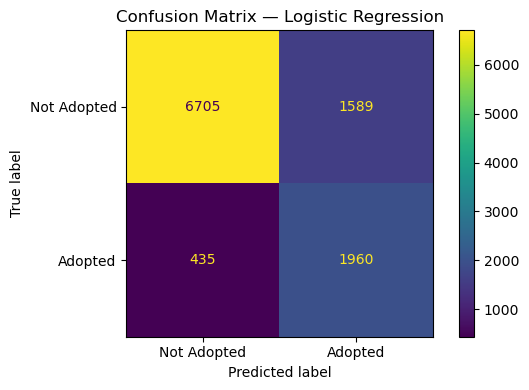

In [8]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_resampled, y_train_resampled)

lr_result = evaluate_model("Logistic Regression", lr, X_test_processed, y_test)
results.append(lr_result)

# Step 5: Decision Tree with Random Search #

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Decision Tree params: {'min_samples_split': 20, 'min_samples_leaf': 8, 'max_depth': 15, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.9270

Model: Decision Tree
              precision    recall  f1-score   support

 Not Adopted       0.92      0.85      0.88      8294
     Adopted       0.59      0.74      0.66      2395

    accuracy                           0.82     10689
   macro avg       0.75      0.80      0.77     10689
weighted avg       0.84      0.82      0.83     10689

ROC-AUC: 0.8747


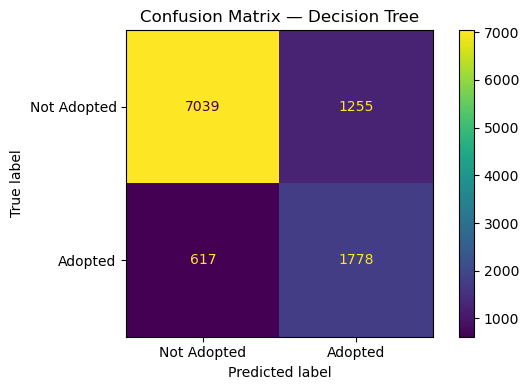

In [10]:
dt_param_dist = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'class_weight': ['balanced']
}

dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_distributions=dt_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
dt_search.fit(X_train_resampled, y_train_resampled)

print(f"Best Decision Tree params: {dt_search.best_params_}")
print(f"Best CV ROC-AUC: {dt_search.best_score_:.4f}")

dt_result = evaluate_model("Decision Tree", dt_search.best_estimator_, X_test_processed, y_test)
results.append(dt_result)

# Step 6: Random Forest with Random Search #

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best CV ROC-AUC: 0.9658

Model: Random Forest
              precision    recall  f1-score   support

 Not Adopted       0.90      0.90      0.90      8294
     Adopted       0.64      0.64      0.64      2395

    accuracy                           0.84     10689
   macro avg       0.77      0.77      0.77     10689
weighted avg       0.84      0.84      0.84     10689

ROC-AUC: 0.8898


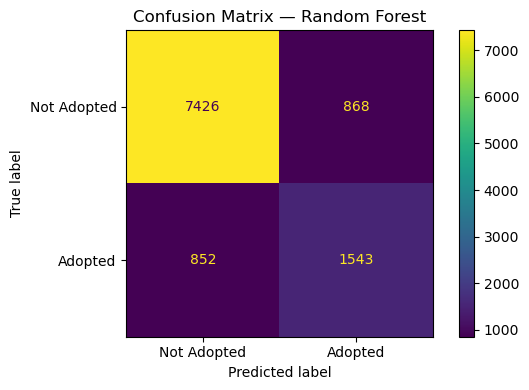

In [12]:
rf_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X_train_resampled, y_train_resampled)

print(f"Best Random Forest params: {rf_search.best_params_}")
print(f"Best CV ROC-AUC: {rf_search.best_score_:.4f}")

rf_result = evaluate_model("Random Forest", rf_search.best_estimator_, X_test_processed, y_test)
results.append(rf_result)

# Step 7: Gradient Boosted Trees with Random Search #

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Gradient Boosting params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 7, 'learning_rate': 0.2}
Best CV ROC-AUC: 0.9671

Model: Gradient Boosting
              precision    recall  f1-score   support

 Not Adopted       0.90      0.90      0.90      8294
     Adopted       0.66      0.67      0.67      2395

    accuracy                           0.85     10689
   macro avg       0.78      0.78      0.78     10689
weighted avg       0.85      0.85      0.85     10689

ROC-AUC: 0.8995


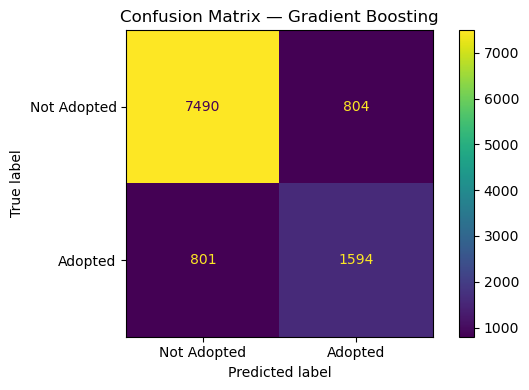

In [14]:
gb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
gb_search.fit(X_train_resampled, y_train_resampled)

print(f"Best Gradient Boosting params: {gb_search.best_params_}")
print(f"Best CV ROC-AUC: {gb_search.best_score_:.4f}")

gb_result = evaluate_model("Gradient Boosting", gb_search.best_estimator_, X_test_processed, y_test)
results.append(gb_result)

# Step 8: XGBoost with Random Search #

scale_pos_weight: 3.46
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGBoost params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
Best CV ROC-AUC: 0.9667

Model: XGBoost
              precision    recall  f1-score   support

 Not Adopted       0.94      0.80      0.87      8294
     Adopted       0.55      0.83      0.66      2395

    accuracy                           0.81     10689
   macro avg       0.75      0.82      0.77     10689
weighted avg       0.86      0.81      0.82     10689

ROC-AUC: 0.8982


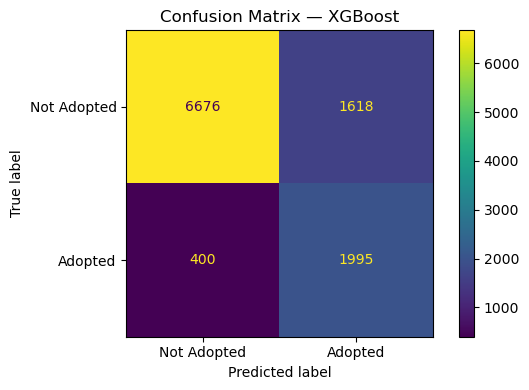

In [16]:
# Calculate scale_pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=5),
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X_train_resampled, y_train_resampled)

print(f"Best XGBoost params: {xgb_search.best_params_}")
print(f"Best CV ROC-AUC: {xgb_search.best_score_:.4f}")

xgb_result = evaluate_model("XGBoost", xgb_search.best_estimator_, X_test_processed, y_test)
results.append(xgb_result)

# Step 9.a: Compare all models #


MODEL COMPARISON SUMMARY
              Model ROC-AUC
Logistic Regression  0.8886
      Decision Tree  0.8747
      Random Forest  0.8898
  Gradient Boosting  0.8995
            XGBoost  0.8982


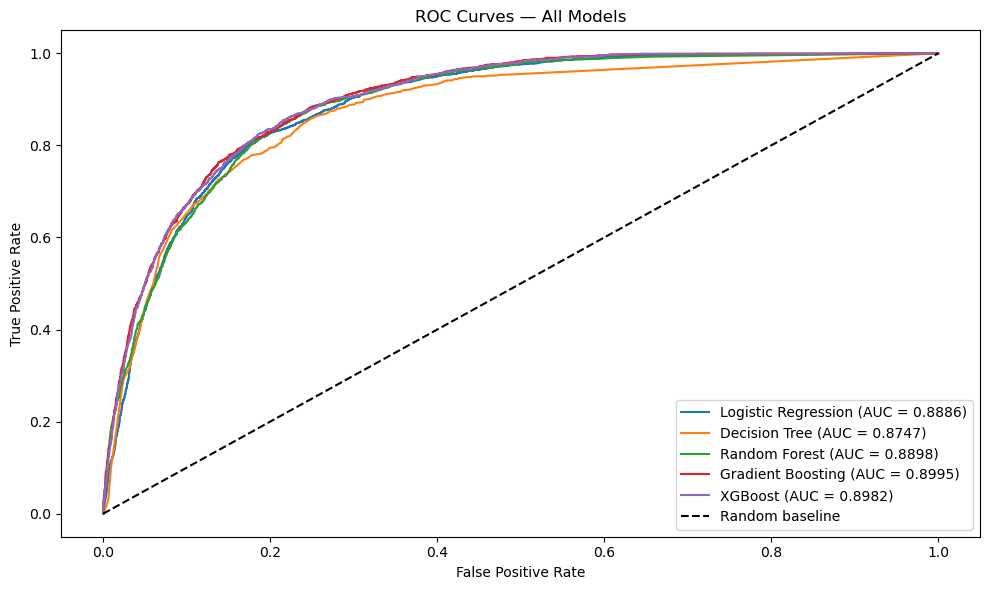

In [18]:
# Summary table
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
summary = pd.DataFrame([{
    'Model': r['name'],
    'ROC-AUC': f"{r['roc_auc']:.4f}"
} for r in results])
print(summary.to_string(index=False))

# ROC curves for all models
plt.figure(figsize=(10, 6))
for r in results:
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    plt.plot(fpr, tpr, label=f"{r['name']} (AUC = {r['roc_auc']:.4f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Step 9b: Cost-sensitive evaluation #


COST-SENSITIVE EVALUATION
Logistic Regression: FN=435, FP=1589, Total Cost=2894
Decision Tree: FN=617, FP=1255, Total Cost=3106
Random Forest: FN=852, FP=868, Total Cost=3424
Gradient Boosting: FN=801, FP=804, Total Cost=3207
XGBoost: FN=400, FP=1618, Total Cost=2818


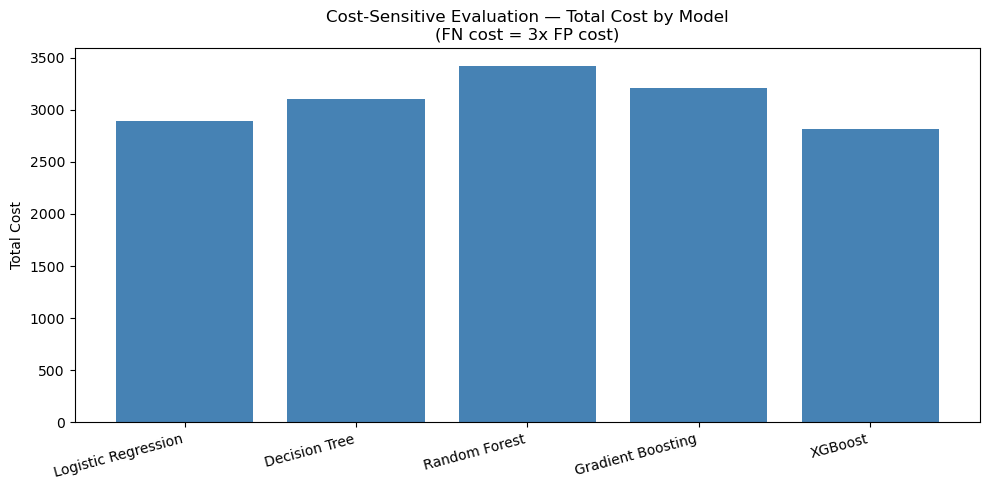

Cost evaluation saved as cost_evaluation.csv


In [20]:
fn_cost = 3  # missing an adoptable animal costs 3x more
fp_cost = 1  # false alarm costs 1x

print("\nCOST-SENSITIVE EVALUATION")
print("="*50)
cost_results = []
for r in results:
    tn, fp, fn, tp = confusion_matrix(y_test, r['y_pred']).ravel()
    total_cost = (fn * fn_cost) + (fp * fp_cost)
    cost_results.append({
        'Model': r['name'],
        'False Negatives': fn,
        'False Positives': fp,
        'Total Cost': total_cost
    })
    print(f"{r['name']}: FN={fn}, FP={fp}, Total Cost={total_cost}")

cost_df = pd.DataFrame(cost_results)

# Plot cost comparison
plt.figure(figsize=(10, 5))
plt.bar(cost_df['Model'], cost_df['Total Cost'], color='steelblue')
plt.title('Cost-Sensitive Evaluation — Total Cost by Model\n(FN cost = 3x FP cost)')
plt.ylabel('Total Cost')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Save for Streamlit
cost_df.to_csv("cost_evaluation.csv", index=False)
print("Cost evaluation saved as cost_evaluation.csv")

# Step 10: Save the best model #

In [22]:
# Identify best model by ROC-AUC
best_result = max(results, key=lambda x: x['roc_auc'])
print(f"\nBest model: {best_result['name']} with ROC-AUC: {best_result['roc_auc']:.4f}")

# Save best model
joblib.dump(best_result['model'], 'best_model.joblib')
print("Best model saved as best_model.joblib")


Best model: Gradient Boosting with ROC-AUC: 0.8995
Best model saved as best_model.joblib


# Step 11: Feature importance analysis #

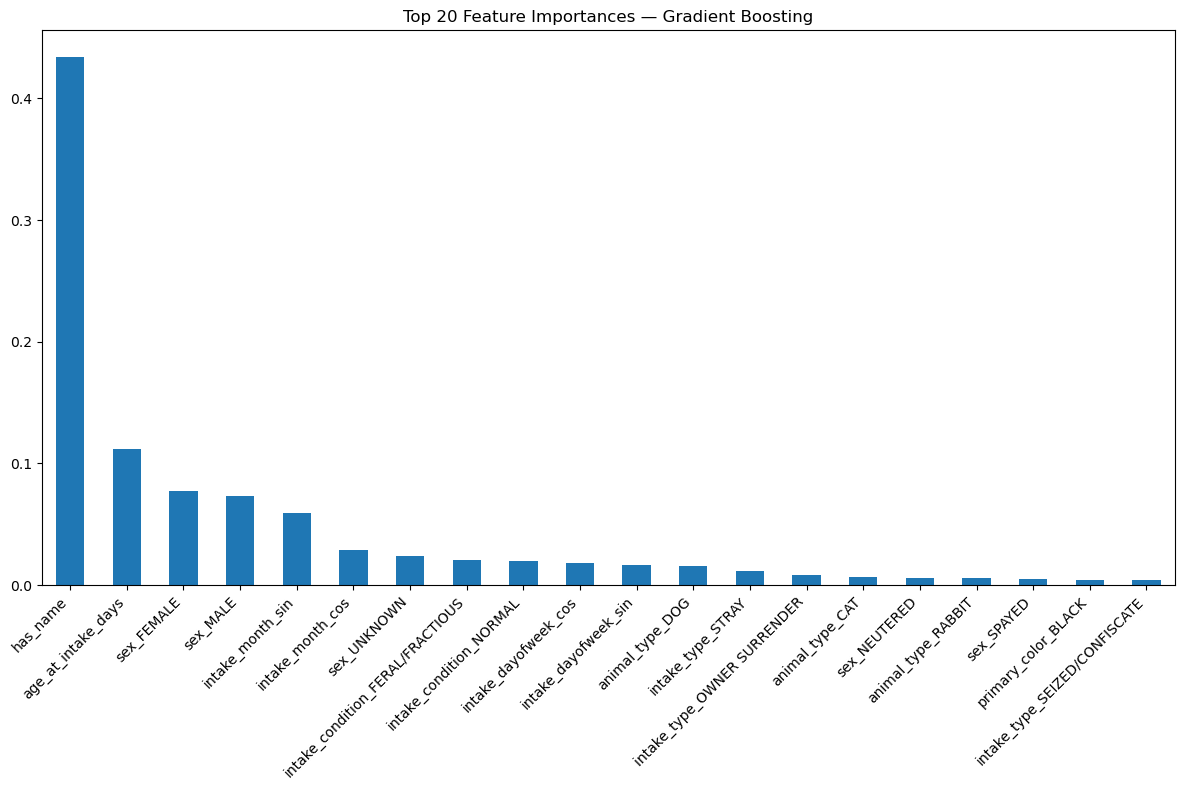

Top 20 Feature Importances:
has_name                            0.434224
age_at_intake_days                  0.111507
sex_FEMALE                          0.077711
sex_MALE                            0.073340
intake_month_sin                    0.059060
intake_month_cos                    0.028452
sex_UNKNOWN                         0.023913
intake_condition_FERAL/FRACTIOUS    0.020765
intake_condition_NORMAL             0.020170
intake_dayofweek_cos                0.018305
intake_dayofweek_sin                0.016244
animal_type_DOG                     0.015377
intake_type_STRAY                   0.011318
intake_type_OWNER SURRENDER         0.008255
animal_type_CAT                     0.006978
sex_NEUTERED                        0.005840
animal_type_RABBIT                  0.005486
sex_SPAYED                          0.004639
primary_color_BLACK                 0.004533
intake_type_SEIZED/CONFISCATE       0.004087
dtype: float64
Feature importances saved as feature_importances.csv


In [24]:
if hasattr(best_result['model'], 'feature_importances_'):
    importances = best_result['model'].feature_importances_
    feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    feat_imp.head(20).plot(kind='bar')
    plt.title(f"Top 20 Feature Importances — {best_result['name']}")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print("Top 20 Feature Importances:")
    print(feat_imp.head(20))

    # Save feature importances for use in Streamlit
    feat_imp.to_csv("feature_importances.csv", header=['importance'])
    print("Feature importances saved as feature_importances.csv")

# Step 12: Save feature names #

In [26]:
# Save feature names for Streamlit
with open('feature_names.json', 'w') as f:
    json.dump(feature_names, f)
print("Feature names saved as feature_names.json")

Feature names saved as feature_names.json


# Step 13: Compute and save SHAP explainer #

In [28]:
# Create SHAP explainer for Gradient Boosting
explainer = shap.TreeExplainer(best_result['model'])

# Save the explainer for use in Streamlit
joblib.dump(explainer, 'shap_explainer.joblib')
print("SHAP explainer saved as shap_explainer.joblib")

# Verify it works on a sample
sample = X_test_processed[:5]
shap_values = explainer.shap_values(sample)

# Handle both array and list outputs
if isinstance(shap_values, list):
    print(f"SHAP values shape: {shap_values[0].shape}")
else:
    print(f"SHAP values shape: {shap_values.shape}")
print("SHAP explainer verified successfully")

SHAP explainer saved as shap_explainer.joblib
SHAP values shape: (5, 46)
SHAP explainer verified successfully


# Step 14: Save data summary statistics for Streamlit visualizations #

In [30]:
df_raw = pd.read_csv("X_train_raw.csv")
print("Columns available:", df_raw.columns.tolist())  # Add this line
y_train_raw = pd.read_csv("y_train.csv")
df_raw['adopted'] = y_train_raw.values.ravel()

# Adoption rate by animal type
adoption_by_type = df_raw.groupby('animal_type')['adopted'].agg(['mean', 'count']).reset_index()
adoption_by_type.columns = ['animal_type', 'adoption_rate', 'count']
adoption_by_type['adoption_rate'] = adoption_by_type['adoption_rate'].round(4)
adoption_by_type = adoption_by_type.sort_values('adoption_rate', ascending=False)
adoption_by_type.to_csv("adoption_by_type.csv", index=False)
print("Adoption by type saved.")
print(adoption_by_type)

# Adoption rate by intake condition
adoption_by_condition = df_raw.groupby('intake_condition')['adopted'].agg(['mean', 'count']).reset_index()
adoption_by_condition.columns = ['intake_condition', 'adoption_rate', 'count']
adoption_by_condition['adoption_rate'] = adoption_by_condition['adoption_rate'].round(4)
adoption_by_condition = adoption_by_condition.sort_values('adoption_rate', ascending=False)
adoption_by_condition.to_csv("adoption_by_condition.csv", index=False)
print("Adoption by condition saved.")
print(adoption_by_condition)

Columns available: ['animal_type', 'primary_color', 'sex', 'intake_condition', 'intake_type', 'has_name', 'age_at_intake_days', 'intake_is_weekend', 'intake_month_sin', 'intake_month_cos', 'intake_dayofweek_sin', 'intake_dayofweek_cos']
Adoption by type saved.
  animal_type  adoption_rate  count
2         DOG         0.2936  13765
3  GUINEA PIG         0.2782    248
5      RABBIT         0.2708    794
1         CAT         0.2541  20225
6     REPTILE         0.0457    460
0        BIRD         0.0197   3089
4       OTHER         0.0159   2134
7        WILD         0.0000   2037
Adoption by condition saved.
       intake_condition  adoption_rate  count
5                NORMAL         0.3155  19115
6                 OTHER         0.3106    763
0              BEHAVIOR         0.2815    373
2      ILL/INJURED MILD         0.2283   3587
7      UNDER AGE/WEIGHT         0.1690   9684
3  ILL/INJURED MODERATE         0.1301   3174
1       FERAL/FRACTIOUS         0.1227   1206
4    ILL/INJURED S

# Step 15: Save model metadata for Streamlit #

In [32]:
model_metadata = {
    'best_model_name': best_result['name'],
    'best_model_roc_auc': round(best_result['roc_auc'], 4),
    'all_models': [
        {
            'name': r['name'],
            'roc_auc': round(r['roc_auc'], 4)
        }
        for r in results
    ]
}

with open('model_metadata.json', 'w') as f:
    json.dump(model_metadata, f)
print("Model metadata saved as model_metadata.json")
print(model_metadata)

Model metadata saved as model_metadata.json
{'best_model_name': 'Gradient Boosting', 'best_model_roc_auc': 0.8995, 'all_models': [{'name': 'Logistic Regression', 'roc_auc': 0.8886}, {'name': 'Decision Tree', 'roc_auc': 0.8747}, {'name': 'Random Forest', 'roc_auc': 0.8898}, {'name': 'Gradient Boosting', 'roc_auc': 0.8995}, {'name': 'XGBoost', 'roc_auc': 0.8982}]}
